In [1]:
#import likely useful libraries
import numpy as np
import pandas as pd
import datetime as dt
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#confirm directory
os.listdir()

['.ipynb_checkpoints',
 'corr_heatmap.png',
 'create_source.png',
 'logins.json',
 'ultimate_data_challenge.json',
 'ultimate_data_science_challenge (1).pdf',
 'ultimate_part1.ipynb',
 'Ultimate_part2.ipynb',
 'Ultimate_part3.ipynb']

In [3]:
#import data
df = pd.read_json('ultimate_data_challenge.json')

#overview of data
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [4]:
#check column data types and for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


signup_date and last_trip_date are object types. we will convert these to datetime objects. avg_rating_of_driver, phone, and avg_rating_by_driver have missing values. We will investigate the NaNs later. first we will create a new column with the target feature "retained"

In [5]:
#convert to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [6]:
#determine what the cutoff date is for the preceding 30 days
df['last_trip_date'].max() - dt.timedelta(days=30)

Timestamp('2014-06-01 00:00:00')

In [7]:
#create new column retained 
df['retained'] = (df['last_trip_date'] >= '2014-06-01').astype(int)

df.tail()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
49995,King's Landing,0,2014-01-25,5.0,1.0,2014-06-05,iPhone,0.0,False,100.0,5.63,4.2,1
49996,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0,0
49997,Winterfell,0,2014-01-31,5.0,1.0,2014-05-22,Android,0.0,True,100.0,3.86,5.0,0
49998,Astapor,2,2014-01-14,3.0,1.0,2014-01-15,iPhone,0.0,False,100.0,4.58,3.5,0
49999,Astapor,0,2014-01-18,NaN,1.0,2014-04-20,Android,0.0,False,0.0,3.49,5.0,0


In [13]:
#get the amounts of non-retained vs. retained
print(df['retained'].value_counts())

#get the amounts of non-retained vs. retained
print(f"Percentage of retained users is {df['retained'].mean()*100:.2f}%")


retained
0    31196
1    18804
Name: count, dtype: int64
Percentage of retained users is 37.61%


Now we can start addressing the missing values in the columns. 

In [14]:
#see if there are any missing rows that also are also True in the retained feature
print(df[df['phone'].isna() & (df['retained']==1)].shape[0])
print(df[df['avg_rating_of_driver'].isna() & (df['retained']==1)].shape[0])
print(df[df['avg_rating_by_driver'].isna() & (df['retained']==1)].shape[0])

133
1632
36


Since most of the missing values belong to "not-retained," we can learn from the missingness itself.
Since the phone feature is categorical, we can add a third category "missing."
For the ratings, we will create a secondary missingness column, then fill the original column with the median.

In [15]:
#impute NaNs with 'missing'
df['phone']=df['phone'].fillna('Missing')
df['phone'].value_counts()

phone
iPhone     34582
Android    15022
Missing      396
Name: count, dtype: int64

In [16]:
#create missingness column
df['avg_rating_of_driver_missing'] = df['avg_rating_of_driver'].isna().astype(int)

#impute NaNs with 'median'
df['avg_rating_of_driver'] = df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].median())

#create missingness column
df['rated_by_driver'] = df['avg_rating_by_driver'].isna().astype(int)

#impute NaNs with 'median'
df['avg_rating_by_driver'] = df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   city                          50000 non-null  object        
 1   trips_in_first_30_days        50000 non-null  int64         
 2   signup_date                   50000 non-null  datetime64[ns]
 3   avg_rating_of_driver          50000 non-null  float64       
 4   avg_surge                     50000 non-null  float64       
 5   last_trip_date                50000 non-null  datetime64[ns]
 6   phone                         50000 non-null  object        
 7   surge_pct                     50000 non-null  float64       
 8   ultimate_black_user           50000 non-null  bool          
 9   weekday_pct                   50000 non-null  float64       
 10  avg_dist                      50000 non-null  float64       
 11  avg_rating_by_driver        

Now that the data is cleaned, we can do EDA

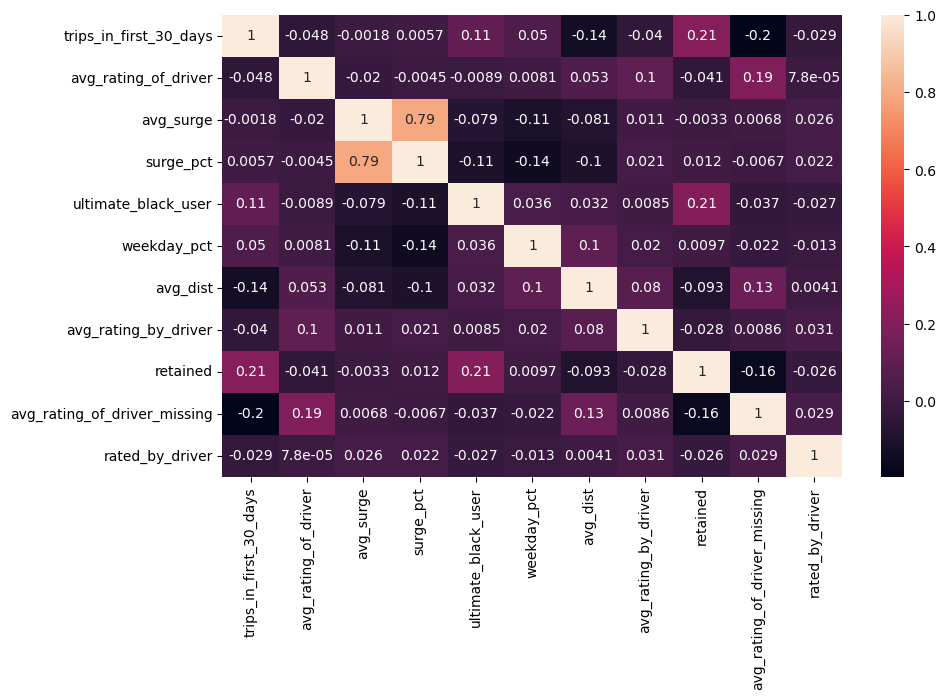

In [17]:
#we can start with a heatmap for numeric data
import scipy.stats as stats

corr = df.corr(numeric_only=True)

# Plot heatmap 
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr, annot=True) 
plt.savefig("corr_heatmap.png", bbox_inches="tight")
plt.show()

While there are no strong correlations from the heatmap, we see that there is a weak correlation between trips in the first 30 days (.21) and ultimate black users (.21), suggesting that users who use the app early, or use the premium service are more likely to be retained. 
In addition, a weak negative correlation is average_rating_of_driver_missing (-.16), suggesting that users who don’t engage in the app (by not taking the time to rate their drivers), are less likely to be retianed

Now we can look at categorical features

In [18]:
#create a function to look at categorical features
def plot_categorical_eda(df, cat_col, target_col='retained'):
    """
    Creates a 3‑panel EDA visualization for a categorical feature:
    1. Mean target rate by category
    2. Countplot with target hue
    3. Stacked percentage bar chart
    """

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    #barplot
    sns.barplot(data=df, x=cat_col, y=target_col, ax=axes[0], estimator='mean')
    axes[0].set_title(f'{target_col.capitalize()} Rate by {cat_col.capitalize()}')
    axes[0].set_ylabel(f'{target_col.capitalize()} Rate')

    #Countplot with hue
    sns.countplot(data=df, x=cat_col, hue=target_col, ax=axes[1])
    axes[1].set_title(f'{target_col.capitalize()} Count by {cat_col.capitalize()}')
    axes[1].set_ylabel('Count')

    #Stacked percentage bar chart
    ct = pd.crosstab(df[cat_col], df[target_col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[2])
    axes[2].set_title(f'Percentage of {target_col.capitalize()} by {cat_col.capitalize()}')
    axes[2].set_ylabel('Proportion')
   

    plt.tight_layout()
    plt.show()


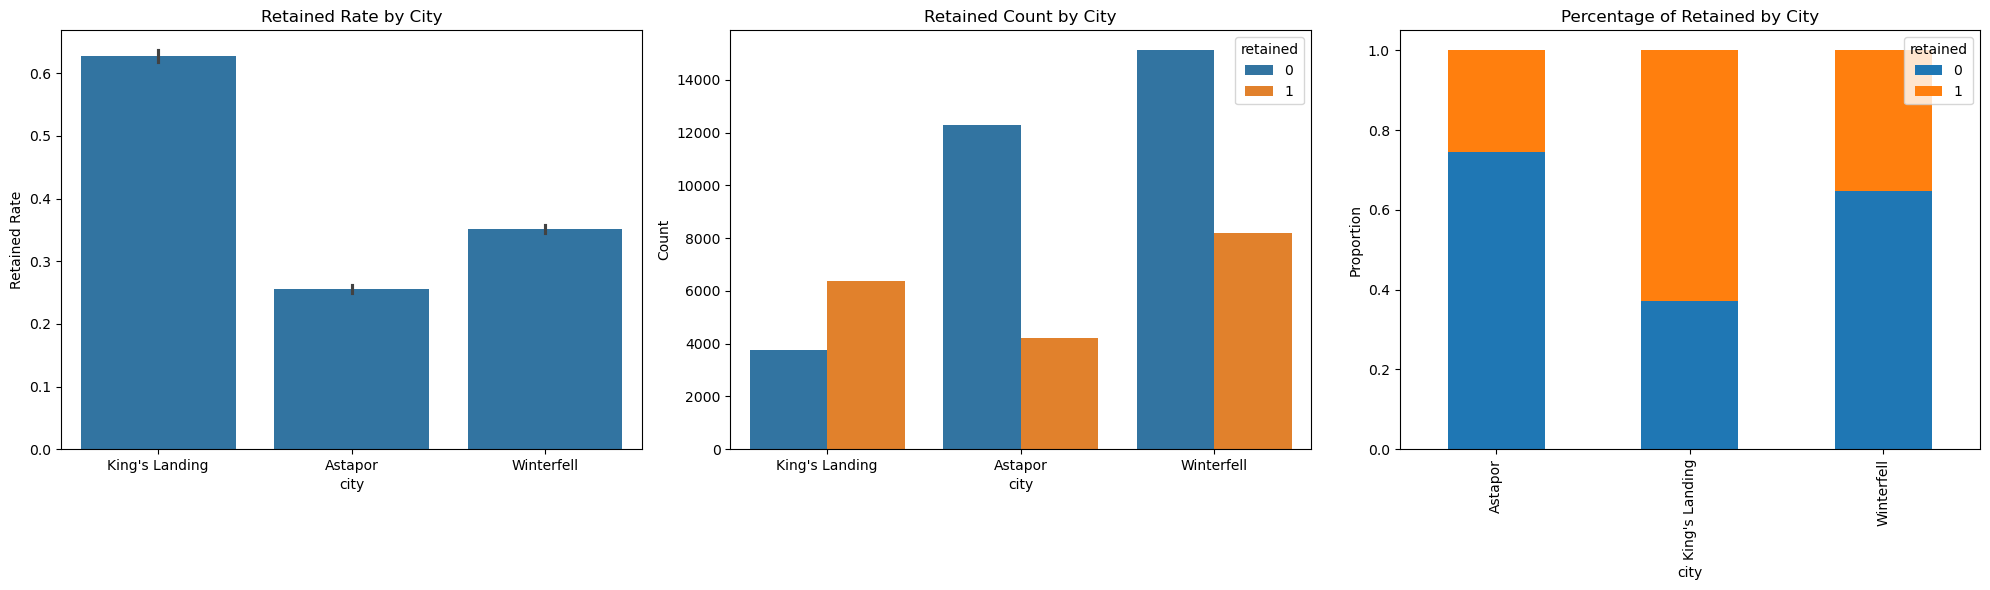

In [19]:
#plot city feature
plot_categorical_eda(df, 'city')

We can see that City as a feature definitely contributes to retention rate, with King's Landing having the best retention rate. While this tells us that city is an indicator, it is important to note that it does not explain why.

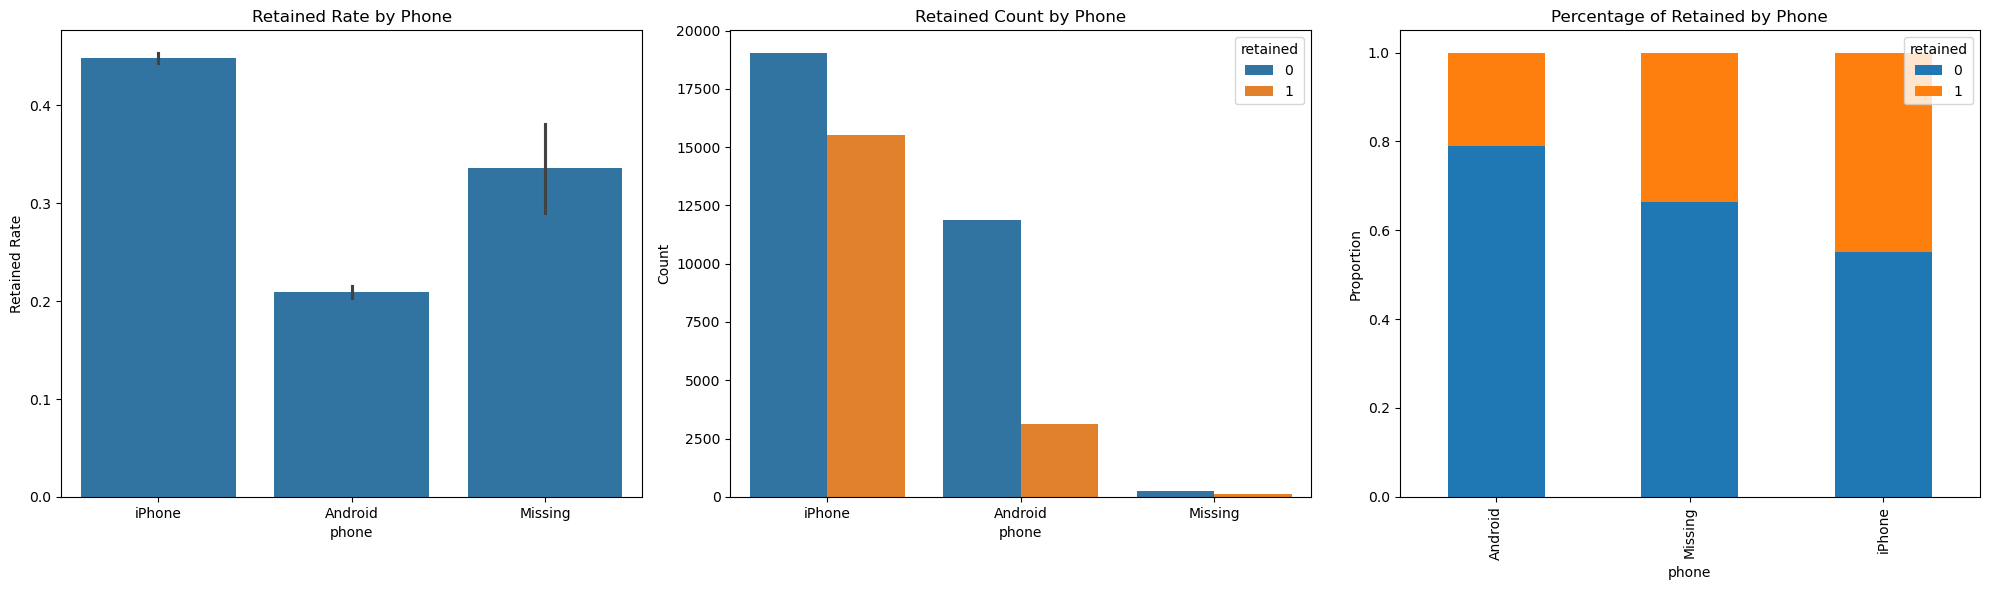

In [20]:
#plit phone type feature
plot_categorical_eda(df, 'phone')

Phone type also shows as an indicator of retention, with iphone users having both a larger use overall and a larger rate of retention.

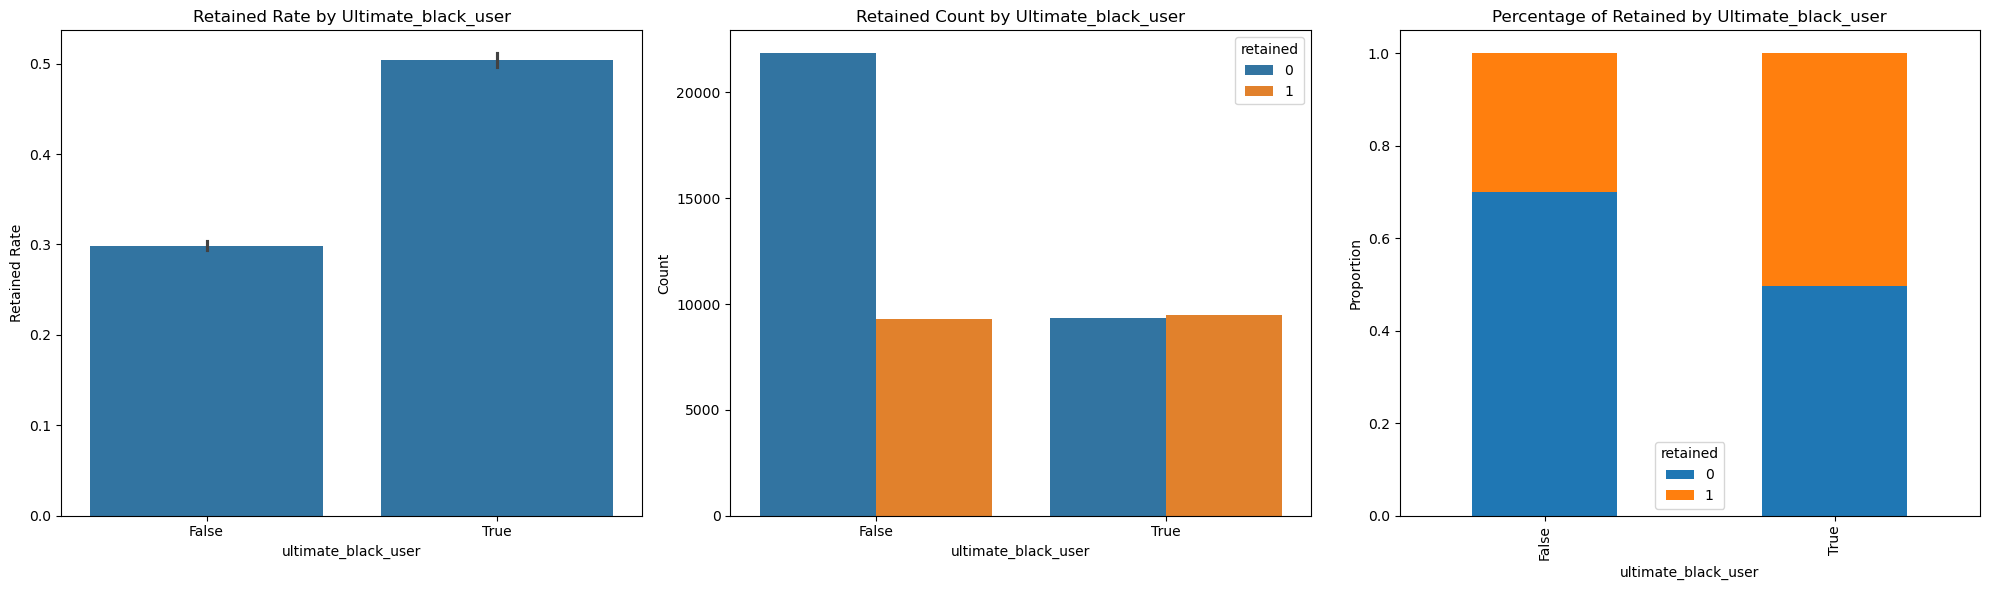

In [21]:
#plot Ultimate black user as a category
plot_categorical_eda(df, 'ultimate_black_user')

As we saw with the heatmap, having ultimate black does contribute to user retention.

Now to preprocess the data

Given our data and features, we will start with a logistic regression model as a baseline, then move on to ensamble tree based models which will likely give better results, as the logistic regression does not work well with non-linear relationships or complex feature interactions.

In [23]:
#create train and test sets
from sklearn.model_selection import train_test_split

#remove features that will interfere with model training and define target feature
X = df.drop(['retained', 'signup_date', 'last_trip_date'], axis=1)
y = df['retained']

#split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
#prepare the a pipeline for use in different models

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#create list for Numeric features
numeric_features = ['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge','surge_pct', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver', \
                    'avg_rating_of_driver_missing', 'rated_by_driver', 'ultimate_black_user']

#create list for Categorical features
categorical_features = ['city', 'phone']

#preprocess numeric features
numeric_transformer = StandardScaler()

#preprocess categorical features
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

#combine into preprocessor
preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])




In [25]:
%%time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

LR= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, verbose=1))])


CPU times: total: 125 ms
Wall time: 200 ms


In [26]:
%%time
LR.fit(X_train, y_train)


CPU times: total: 156 ms
Wall time: 227 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver',
                                                   'avg_rating_of_driver_missing',
                                                   'rated_by_driver',
                                                   'ultimate_black_user']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['city', 'phone'])])),
                ('classifier', LogisticRegression(random_state=42, verbose=1))])

In [27]:
%%time
y_pred_LR = LR.predict(X_test)
y_probs_LR = LR.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred_LR))


Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.85      0.79      6239
           1       0.67      0.50      0.57      3761

    accuracy                           0.72     10000
   macro avg       0.71      0.68      0.68     10000
weighted avg       0.71      0.72      0.71     10000

CPU times: total: 62.5 ms
Wall time: 73.4 ms


In [28]:
auc_score_LR = roc_auc_score(y_test, y_probs_LR)
print(f"ROC-AUC Score: {auc_score_LR:.4f}")

ROC-AUC Score: 0.7599


This results give a decent baseline model. Let us see if we can improve with tree based models

In [29]:
%%time
#create random forest model
from sklearn.ensemble import RandomForestClassifier
RF= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, verbose=2 ))])

CPU times: total: 93.8 ms
Wall time: 200 ms


In [30]:
%%time
RF.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.1s


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver',
                                                   'avg_rating_of_driver_missing',
                                                   'rated_by_driver',
                                                   'ultimate_black_user']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['city', 'phone'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42,
                                        verbose=2))])

In [31]:
%%time
y_pred_RF = RF.predict(X_test)
y_probs_RF = RF.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred_RF))


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81      6239
           1       0.69      0.66      0.67      3761

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000

CPU times: total: 672 ms
Wall time: 154 ms


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [32]:
auc_score_RF = roc_auc_score(y_test, y_probs_RF)
print(f"ROC-AUC Score: {auc_score_RF:.4f}")

ROC-AUC Score: 0.8255


We can see this model preformed better than the logistic regression model

In [34]:
%%time
#create xgboost model
import xgboost as xgb

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42))])

CPU times: total: 0 ns
Wall time: 515 μs


In [35]:
%%time
xgb.fit(X_train, y_train)

CPU times: total: 1.14 s
Wall time: 355 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver',
                                                   'avg_rating_of_driver_missing',
                                                   'rated_by_driver',
                                                   'ultimate_black_user']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['city', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [36]:
%%time
y_pred_xgb = xgb.predict(X_test)
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84      6239
           1       0.75      0.67      0.71      3761

    accuracy                           0.79     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.79      0.79      0.79     10000

CPU times: total: 250 ms
Wall time: 69.8 ms


In [37]:
auc_score_xgb = roc_auc_score(y_test, y_probs_xgb)
print(f"ROC-AUC Score: {auc_score_xgb:.4f}")

ROC-AUC Score: 0.8572


The XGboost model preformed slightly better than the random forest model

In [38]:
#create light GBM model
import lightgbm as lgb
lgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42))])

In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lgb, X_train, y_train, cv=5, scoring='roc_auc')

print(f"All CV AUC Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

[LightGBM] [Info] Number of positive: 12034, number of negative: 19966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376063 -> initscore=-0.506295
[LightGBM] [Info] Start training from score -0.506295
[LightGBM] [Info] Number of positive: 12034, number of negative: 19966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 14
[LightGBM] [Info] [b

In [40]:
%%time
lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 15043, number of negative: 24957
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376075 -> initscore=-0.506242
[LightGBM] [Info] Start training from score -0.506242
CPU times: total: 1.59 s
Wall time: 392 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver',
                                                   'avg_rating_of_driver_missing',
                                                   'rated_by_driver',
                                                   'ultimate_black_user']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['city', 'phone'])])),
                ('classifier', LGBMClassifier(random_state=42))])

In [41]:
%%time
y_pred_lgb = lgb.predict(X_test)
y_probs_lgb = lgb.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84      6239
           1       0.75      0.67      0.71      3761

    accuracy                           0.79     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.79      0.79      0.79     10000

CPU times: total: 828 ms
Wall time: 178 ms


In [42]:
auc_score_lgb = roc_auc_score(y_test, y_probs_lgb)
print(f"ROC-AUC Score: {auc_score_lgb:.4f}")

ROC-AUC Score: 0.8606


The Light GBM model preformed similarly to the xgboost model, with slight higher ROC-AUC score.

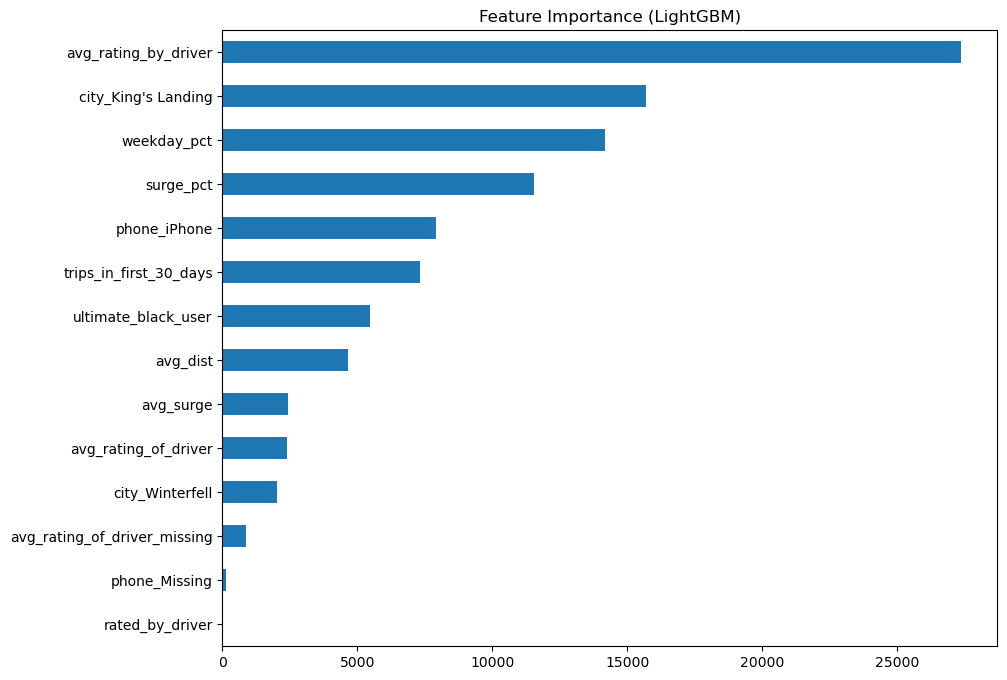

In [50]:
#Get feature names from the preprocessor
cat_features = lgb.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out()
num_features = numeric_features
all_features = num_features + list(cat_features)

# Get importances from the model
importances = lgb.named_steps['classifier'].booster_.feature_importance(importance_type='gain')

#Create a DataFrame and Plot
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)
feat_imp.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance (LightGBM)')
plt.show()

This visualization tells us which features the model considered most important, however it does not tell us whether the impact is positive or negative (i.e. more likely or less likely to retain). We can use SHAP values to get more in depth information. 

C:\Users\steve\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


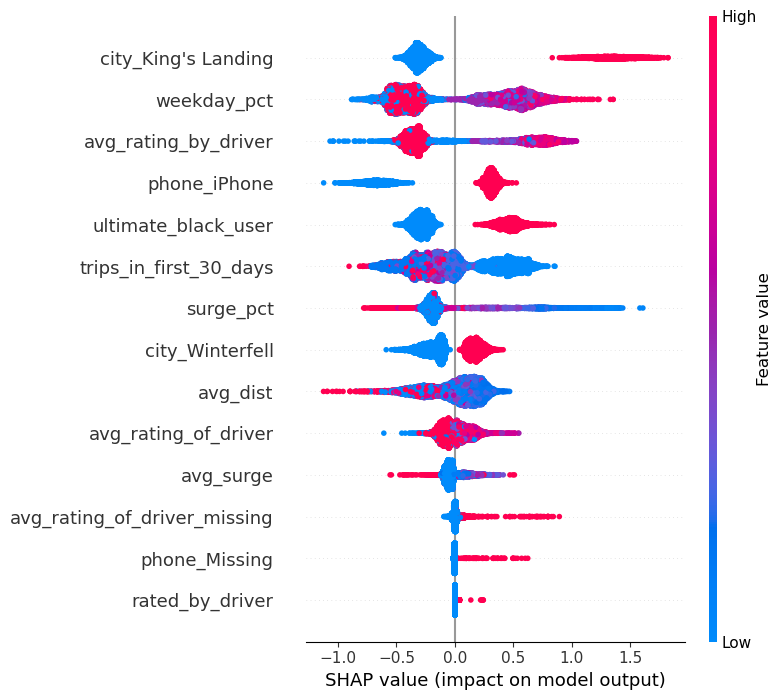

In [54]:
#create SHAP
import shap

#extract preprocessor and trained classifier from pipeline
preprocessor = lgb.named_steps['preprocessor']
classifier = lgb.named_steps['classifier']

#get feature names after one-hot encoding
cat_features = preprocessor.transformers_[1][1].get_feature_names_out()
num_features = numeric_features
all_features = num_features + list(cat_features)

#transform the test data using the preprocessor step
X_test_transformed = preprocessor.transform(X_test)

#convert to DataFrame with feature names for cleaner SHAP plots
if not isinstance(X_test_transformed, pd.DataFrame):
    X_test_transformed = pd.DataFrame(X_test_transformed, columns=all_features)

#initialize SHAP TreeExplainer on the classifier
explainer = shap.TreeExplainer(classifier)

#calculate SHAP values for the transformed test set
shap_values = explainer.shap_values(X_test_transformed)


if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

#plot the SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_to_plot, X_test_transformed)

Based on the importances and SHAP values, we can see that the biggest indicators of retention are the location, where users in King’s landing are significantly more likely to be retained; weekday users( i.e. commuters vs weekend trips), where weekday users are more likely to be retained; average rating by driver, where high ratings from the driver indicate the user is more likely to be retained (higher rating likely mean better behavior/etiquette learned from repeated rides); Phone type, where iPhone users are more likely to be retained; being an ultimate black user (likely because investing in the higher tier makes users want to use the service to make sure they are getting the most out of their payment); trips in the first 30 days, where taking more trips early means the user is more likely to build a routine and continue using the app.

To keep more riders around long-term, Ultimate should focus on helping new users build a habit early and fixing issues in struggling areas. They can offer discount deals during a user’s first month to get them riding regularly, promote premium options like Ultimate Black, and copy what's working so well in King's Landing. At the same time, they can reduce churn in cities like Astapor by easing up on high surge prices and offering better deals for riders who take longer trips. Additionally, they can push advertisments and deals to android users to try to get more to try the service